# Model building 1
Initial model 1 is trained on BWC 160 - 200, and tested on BWC 201 - 208

This experiment focuses on only classification of Early Streaming (Stage 1), not streaming into Fighters (Stage 2)

## Imports

In [18]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

## Constants

In [19]:
COLUMNS_TO_DROP = ["STUDENT_ID","AWC_stream", "AWC_stream_binary", "BWC_status_binary"]
TARGET_COLUMN = "BWC_status_binary"

## Loading of datasets
Use BWC Batch 160-200 for training. \
BWC Batch 201-208 will be used for evaluation later on.

In [20]:
df1 = pd.read_csv("../data/cleaned_early_streaming_t201.csv").dropna(subset = "BWC_status_binary")
df2 = pd.read_csv("../data/cleaned_201t208.csv").dropna(subset = "BWC_status_binary")

df1

,STUDENT_ID,GH 1,GH 2,GH 3,GH 4,GH 5,GH 6,GH 7,GH 8,GH 9,...,IF 1,IF 2,IF 3,IF 4,IF 5,IF 6,IFT,AWC_stream,AWC_stream_binary,BWC_status_binary
0,160CHANC,4.215324,3.937536,4.000000,3.736023,3.726859,3.747200,3.210893,2.673016,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,160CHANG,3.926446,3.746286,4.094832,4.036967,4.111887,3.783657,2.528977,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,160CHOOC,4.243429,4.379660,4.674136,4.110342,3.962646,3.928343,4.000000,3.901540,4.304875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1
3,160HOS,4.572844,4.476572,4.458939,3.850272,4.074621,4.110372,4.385034,4.229443,4.486146,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1
4,160HOWW,4.936332,4.061821,3.903645,3.581086,3.133589,3.390447,1.487395,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,200TERJ,4.858383,5.098765,4.722091,4.293651,4.182033,3.743067,4.467533,3.699077,4.191245,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
582,200TEWJ,5.813411,5.653140,5.094496,5.210907,4.576538,5.086124,4.853173,4.721885,4.454959,...,5.552131,5.111225,4.810760,4.898658,4.164966,4.266431,4.406520,5.0,1.0,1
583,200VVARUN,5.714286,5.591837,5.101195,4.696520,4.860699,4.445996,4.272728,4.173890,4.412128,...,4.850349,4.607360,4.696551,4.388513,4.277323,4.166171,4.347469,3.0,0.0,1
584,200WEEW,5.054227,5.153390,4.398210,4.774973,4.965671,5.120336,4.776854,4.671114,3.729477,...,4.672861,4.656508,4.441327,4.000000,3.945963,3.923590,4.511375,3.0,0.0,1


In [21]:
df2

,STUDENT_ID,GH 1,GH 2,GH 3,GH 4,GH 5,GH 6,GH 7,GH 8,GH 9,...,IF 1,IF 2,IF 3,IF 4,IF 5,IF 6,IFT,AWC_stream,AWC_stream_binary,BWC_status_binary
0,201EEZ,NaN,NaN,5.234087,NaN,NaN,4.367075,NaN,NaN,4.135952,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,201HLEE,4.624989,NaN,NaN,NaN,NaN,NaN,4.155844,4.118668,5.054041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,201HONT,5.113508,NaN,NaN,NaN,NaN,4.735986,NaN,NaN,4.000000,...,NaN,4.245510,4.539404,4.406282,3.777039,NaN,NaN,NaN,NaN,0.0
3,201KHOOC,NaN,NaN,NaN,4.634096,NaN,NaN,NaN,NaN,4.272362,...,5.377912,5.277256,NaN,4.386612,NaN,NaN,4.204591,2.0,0.0,1.0
4,201KOHZ,NaN,NaN,5.756446,4.930210,4.751955,NaN,NaN,NaN,5.286757,...,NaN,4.491836,4.585104,3.000000,NaN,3.785039,NaN,1.0,1.0,1.0
5,201KSARAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.197280,3.904473,...,4.270524,2.000000,4.306142,4.388513,NaN,NaN,NaN,3.0,0.0,1.0
6,201LEEJ,5.116952,NaN,NaN,NaN,NaN,4.388821,NaN,NaN,NaN,...,4.628361,4.860992,NaN,4.468097,4.295469,3.913083,4.211606,1.0,1.0,1.0
7,201LIMK,NaN,5.653140,NaN,NaN,NaN,NaN,NaN,4.456488,4.684353,...,2.000000,NaN,4.278003,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,201ONGE,5.116952,NaN,NaN,NaN,NaN,4.731633,NaN,4.641768,NaN,...,4.225564,NaN,NaN,NaN,NaN,4.486976,NaN,1.0,1.0,1.0
9,201PANGM,NaN,NaN,4.975985,NaN,NaN,5.180113,NaN,NaN,NaN,...,NaN,4.601960,NaN,2.000000,4.260308,NaN,NaN,2.0,0.0,1.0


In [22]:
df1.columns

Index(['STUDENT_ID', 'GH 1', 'GH 2', 'GH 3', 'GH 4', 'GH 5', 'GH 6', 'GH 7',
       'GH 8', 'GH 9', 'GH 10', 'GH 11', 'GH 12', 'GH 13', 'GH 14', 'GH 15',
       'GH 17', 'GH 19', 'GH 21', 'GH 22', 'GH 24', 'GH 25', 'GH 27', 'GH 28',
       'GH 29', 'GH 30', 'GH 31', 'GH 32', 'GH 33', 'GH 34', 'GH 35', 'IF 1',
       'IF 2', 'IF 3', 'IF 4', 'IF 5', 'IF 6', 'IFT', 'AWC_stream',
       'AWC_stream_binary', 'BWC_status_binary'],
      dtype='str')

In [23]:
df1.dtypes

STUDENT_ID               str
GH 1                 float64
GH 2                 float64
GH 3                 float64
GH 4                 float64
GH 5                 float64
GH 6                 float64
GH 7                 float64
GH 8                 float64
GH 9                 float64
GH 10                float64
GH 11                float64
GH 12                float64
GH 13                float64
GH 14                float64
GH 15                float64
GH 17                float64
GH 19                float64
GH 21                float64
GH 22                float64
GH 24                float64
GH 25                float64
GH 27                float64
GH 28                float64
GH 29                float64
GH 30                float64
GH 31                float64
GH 32                float64
GH 33                float64
GH 34                float64
GH 35                float64
IF 1                 float64
IF 2                 float64
IF 3                 float64
IF 4          

## Creating Train, Val, and Test DataFrame
BWC 160 - 200 will be split 80-20 into train and validation set \
BWC 201 - 208 (only with non-NaN ground truth label) will be used as the test set

In [24]:
X = df1.drop(columns=COLUMNS_TO_DROP)
y = df1[TARGET_COLUMN]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,    
)

In [25]:
X_test = df2.drop(columns=COLUMNS_TO_DROP)
y_test = df2[TARGET_COLUMN]

### Training initial model

In [26]:
initial_model1 = RandomForestClassifier(
    n_estimators = 1000,
    max_depth = 6,
    min_samples_split = 5,
    min_samples_leaf = 1,
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1,
)

initial_model1.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Validating initial model

In [27]:
y_pred = initial_model1.predict(X_val)
print(classification_report(y_val, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred)}")

              precision    recall  f1-score   support

           0       0.84      0.98      0.90        42
           1       0.99      0.89      0.94        76

    accuracy                           0.92       118
   macro avg       0.91      0.94      0.92       118
weighted avg       0.93      0.92      0.92       118

ROC-AUC: 0.9354636591478697


### Testing on BWC 201 - 208

In [28]:
y_test_pred = initial_model1.predict(X_test)
print(classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_pred)}")

              precision    recall  f1-score   support

         0.0       0.53      0.94      0.68        18
         1.0       0.96      0.64      0.77        42

    accuracy                           0.73        60
   macro avg       0.75      0.79      0.73        60
weighted avg       0.83      0.73      0.74        60

ROC-AUC: 0.7936507936507936


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### Initial findings
Definition of terms:
- `class 1` = BWC cadet goes for early streaming
- `class 0` = BWC cadet does **not** go for early streaming

For `class 1`, it can be said that the model is quite conservative in identifying cadets to send for early streaming.\
A recall score of $0.64$ means that the model missed out about $36\%$ of actual early streaming cadets i.e. ~$15$ early streaming cadets were classified as non-early streaming. \
However, it is quite precise in identifying early streaming cadets as $96\%$ ($27 / 28$) of cadets identified as early streaming were **actually** in early streaming.

For `class 0`, the model tends to over-predict this class i.e. it is quite strict in identifying `class 1` cadets, as explained above.


## Tuning `initial_model1`

=== Cross-Validation Results (Initial Model) ===
  roc_auc             : 0.9665 ± 0.0126
  f1_macro            : 0.9170 ± 0.0246
  f1_weighted         : 0.9219 ± 0.0234
  recall_class1       : 0.9364 ± 0.0198
  precision_class1    : 0.9364 ± 0.0198
Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== Best Hyperparameters ===
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.3, 'max_depth': None, 'class_weight': 'balanced_subsample'}
Best CV ROC-AUC: 0.9707

=== Best Threshold (by macro F1) ===
threshold       0.350000
f1_macro        0.933618
f1_class1       0.951743
recall_c1       0.967302
precision_c1    0.936675
roc_auc         0.969642

=== Final Classification Report (threshold=0.35) ===
              precision    recall  f1-score   support

           0       0.94      0.89      0.92       219
           1       0.94      0.97      0.95       367

    accuracy                           0.94       586
   macro avg       0.94     

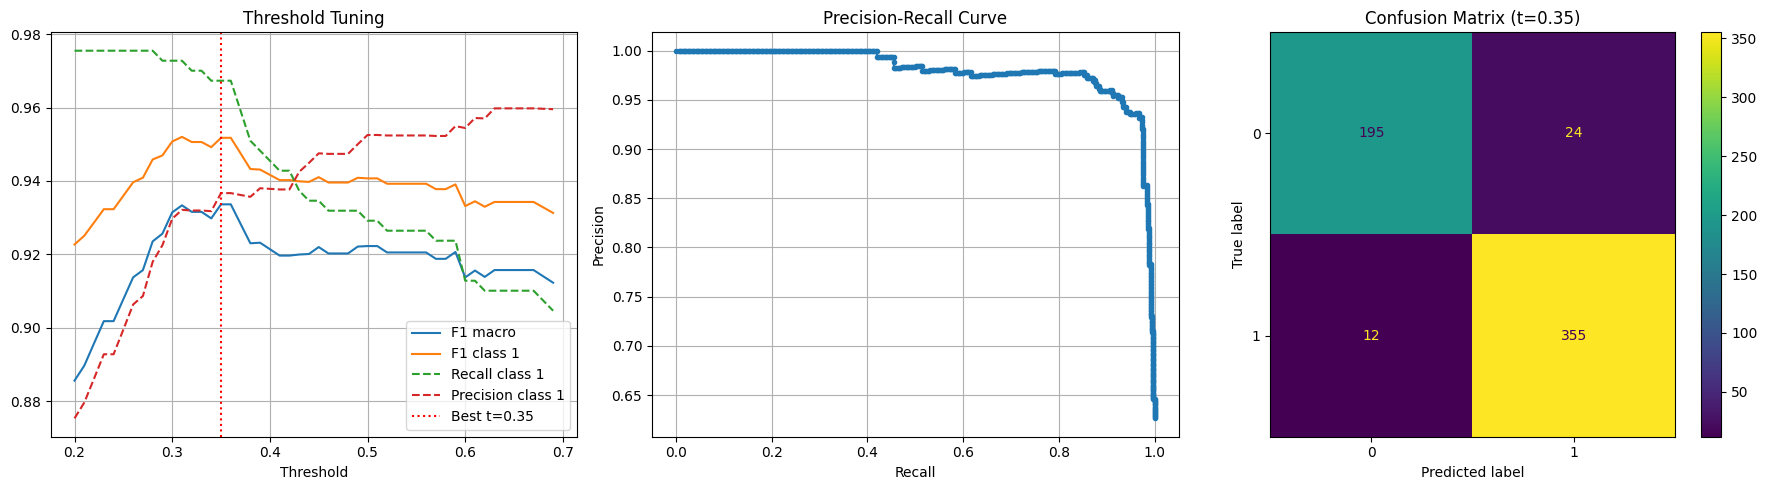

In [29]:
# ─────────────────────────────────────────────
# 1. CROSS-VALIDATION ON INITIAL MODEL
# ─────────────────────────────────────────────
initial_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc":          "roc_auc",
    "f1_macro":         "f1_macro",
    "f1_weighted":      "f1_weighted",
    "recall_class1":    make_scorer(f1_score, pos_label=1),
    "precision_class1": make_scorer(f1_score, pos_label=1),
}

cv_results = cross_validate(
    initial_model, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

print("=== Cross-Validation Results (Initial Model) ===")
for metric, scores in cv_results.items():
    if metric.startswith("test_"):
        print(f"  {metric[5:]:20s}: {scores.mean():.4f} ± {scores.std():.4f}")

# ─────────────────────────────────────────────
# 2. HYPERPARAMETER TUNING (RandomizedSearchCV)
# ─────────────────────────────────────────────
param_dist = {
    "n_estimators":     [200, 500, 1000, 1500],
    "max_depth":        [4, 5, 6, 7, 8, None],
    "min_samples_split":[2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features":     ["sqrt", "log2", 0.3, 0.5],
    "class_weight":     ["balanced", "balanced_subsample"],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=60,                      # increase for more thorough search
    scoring="roc_auc",              # optimize for AUC
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(X, y)

print("\n=== Best Hyperparameters ===")
print(search.best_params_)
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

best_model = search.best_estimator_

# ─────────────────────────────────────────────
# 3. THRESHOLD TUNING ON BEST MODEL
# ─────────────────────────────────────────────
# Use out-of-fold probabilities for honest threshold search
from sklearn.model_selection import cross_val_predict

y_prob_oof = cross_val_predict(
    best_model, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Sweep thresholds
thresholds = np.arange(0.20, 0.70, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_prob_oof >= t).astype(int)
    results.append({
        "threshold":   t,
        "f1_macro":    f1_score(y, y_pred_t, average="macro"),
        "f1_class1":   f1_score(y, y_pred_t, pos_label=1),
        "recall_c1":   np.sum((y_pred_t == 1) & (y == 1)) / np.sum(y == 1),
        "precision_c1":np.sum((y_pred_t == 1) & (y == 1)) / (np.sum(y_pred_t == 1) + 1e-9),
        "roc_auc":     roc_auc_score(y, y_prob_oof),
    })

thresh_df = pd.DataFrame(results)

# Best threshold by macro F1
best_thresh_row = thresh_df.loc[thresh_df["f1_macro"].idxmax()]
best_threshold = best_thresh_row["threshold"]

print(f"\n=== Best Threshold (by macro F1) ===")
print(best_thresh_row.to_string())

# ─────────────────────────────────────────────
# 4. FINAL EVALUATION WITH BEST THRESHOLD
# ─────────────────────────────────────────────
y_pred_final = (y_prob_oof >= best_threshold).astype(int)

print(f"\n=== Final Classification Report (threshold={best_threshold:.2f}) ===")
print(classification_report(y, y_pred_final))
print(f"ROC-AUC: {roc_auc_score(y, y_prob_oof):.4f}")

# ─────────────────────────────────────────────
# 5. PLOTS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Threshold vs F1
axes[0].plot(thresh_df["threshold"], thresh_df["f1_macro"],    label="F1 macro")
axes[0].plot(thresh_df["threshold"], thresh_df["f1_class1"],   label="F1 class 1")
axes[0].plot(thresh_df["threshold"], thresh_df["recall_c1"],   label="Recall class 1", linestyle="--")
axes[0].plot(thresh_df["threshold"], thresh_df["precision_c1"],label="Precision class 1", linestyle="--")
axes[0].axvline(best_threshold, color="red", linestyle=":", label=f"Best t={best_threshold:.2f}")
axes[0].set_title("Threshold Tuning")
axes[0].set_xlabel("Threshold")
axes[0].legend()
axes[0].grid(True)

# (b) Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y, y_prob_oof)
axes[1].plot(recall_curve, precision_curve, marker=".")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].grid(True)

# (c) Confusion Matrix
cm = confusion_matrix(y, y_pred_final)
ConfusionMatrixDisplay(cm).plot(ax=axes[2])
axes[2].set_title(f"Confusion Matrix (t={best_threshold:.2f})")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 6. SAVE BEST MODEL + THRESHOLD
# ─────────────────────────────────────────────
# import joblib

# joblib.dump(best_model, "best_rf_model.joblib")
# joblib.dump(best_threshold, "best_threshold.joblib")

# print(f"\nSaved: best_rf_model.joblib, best_threshold.joblib")
# print(f"Use threshold={best_threshold:.2f} when deploying to Power Apps")

In [30]:
y_test_pred = best_model.predict(X_test)
print(classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_pred)}")

              precision    recall  f1-score   support

         0.0       0.45      0.94      0.61        18
         1.0       0.95      0.50      0.66        42

    accuracy                           0.63        60
   macro avg       0.70      0.72      0.63        60
weighted avg       0.80      0.63      0.64        60

ROC-AUC: 0.7222222222222221
